# Benchmark comparison (package client)

This notebook regenerates the compact synthetic benchmark artifacts used by the results documentation. It delegates the benchmark run to `scripts/generate_comparison_results.py` and then displays the committed CSV outputs.

Outputs:
- `results/generated_comparison_summary.csv`
- `results/generated_repeatability_trials.csv`

In [1]:
from __future__ import annotations

import csv
import importlib
import sys
from pathlib import Path

from IPython.display import Markdown, display


def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists():
            return path
    raise RuntimeError("Could not locate repository root containing pyproject.toml.")


ROOT = find_repo_root(Path.cwd().resolve())

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

generate_results = importlib.import_module("scripts.generate_comparison_results").main
plotting = importlib.import_module("vqe_portfolio.plotting")
plot_comparison_metric_bars = plotting.plot_comparison_metric_bars
plot_risk_return_comparison = plotting.plot_risk_return_comparison

SUMMARY_CSV = ROOT / "results" / "generated_comparison_summary.csv"
TRIALS_CSV = ROOT / "results" / "generated_repeatability_trials.csv"
IMAGE_DIR = ROOT / "notebooks" / "images"

## Generate benchmark artifacts

In [2]:
generate_results(
    [
        "--output",
        str(SUMMARY_CSV),
        "--trials-output",
        str(TRIALS_CSV),
        "--asset-counts",
        "4",
        "--seeds",
        "0,1,2",
        "--methods",
        "all",
        "--steps",
        "25",
        "--shots",
        "512",
    ]
)

Wrote 9 summary rows to /workspaces/VQE_Portfolio_Optimization/results/generated_comparison_summary.csv
Wrote 17 trial rows to /workspaces/VQE_Portfolio_Optimization/results/generated_repeatability_trials.csv


0

## Display helpers

In [3]:
def read_rows(path: Path) -> list[dict[str, str]]:
    with path.open(newline="") as f:
        return list(csv.DictReader(f))


def markdown_table(
    rows: list[dict[str, str]], columns: list[str], limit: int | None = None
) -> Markdown:
    shown = rows if limit is None else rows[:limit]
    header = "| " + " | ".join(columns) + " |"
    rule = "| " + " | ".join("---" for _ in columns) + " |"
    body = [
        "| " + " | ".join(str(row.get(col, "")) for col in columns) + " |"
        for row in shown
    ]
    return Markdown("\n".join([header, rule, *body]))


summary_rows = read_rows(SUMMARY_CSV)
trial_rows = read_rows(TRIALS_CSV)

## Summary comparison

In [4]:
display(
    markdown_table(
        summary_rows,
        [
            "dataset",
            "method",
            "type",
            "objective_family",
            "reported_weighting",
            "seed_count",
            "best_objective",
            "mean_objective",
            "std_objective",
            "feasible_rate",
            "best_selection_or_weights",
        ],
    )
)

| dataset | method | type | objective_family | reported_weighting | seed_count | best_objective | mean_objective | std_objective | feasible_rate | best_selection_or_weights |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Synthetic generated n=4 | Classical exhaustive search | classical | binary_qubo | equal_weight_selected | 1 | 0.285137 | 0.285137 | 0.000000 | 1.000000 | 1010 |
| Synthetic generated n=4 | Classical top-return heuristic | classical heuristic | binary_qubo | equal_weight_selected | 1 | 0.377932 | 0.377932 | 0.000000 | 1.000000 | 0011 |
| Synthetic generated n=4 | Classical minimum-variance subset | classical heuristic | binary_qubo | equal_weight_selected | 1 | 0.285137 | 0.285137 | 0.000000 | 1.000000 | 1010 |
| Synthetic generated n=4 | Classical equal weight | classical heuristic | fractional_simplex | simplex_weights | 1 | -0.050496 | -0.050496 | 0.000000 | 1.000000 | [0.250000 0.250000 0.250000 0.250000] |
| Synthetic generated n=4 | Classical exact Markowitz | classical | fractional_simplex | simplex_weights | 1 | -0.053292 | -0.053292 | 0.000000 | 1.000000 | [0.197536 0.220799 0.308951 0.272714] |
| Synthetic generated n=4 | Binary VQE best feasible | quantum | binary_qubo | equal_weight_selected | 3 | 0.285137 | 0.289414 | 0.006049 | 0.978516 | 1010 |
| Synthetic generated n=4 | QAOA X best feasible | quantum | binary_qubo | equal_weight_selected | 3 | 0.285137 | 0.285137 | 0.000000 | 0.699219 | 1010 |
| Synthetic generated n=4 | QAOA XY best feasible | quantum | binary_qubo | equal_weight_selected | 3 | 0.285137 | 0.285137 | 0.000000 | 1.000000 | 1010 |
| Synthetic generated n=4 | Fractional VQE | quantum | fractional_simplex | simplex_weights | 3 | -0.053289 | -0.052921 | 0.000415 | 1.000000 | [0.196860 0.219772 0.308378 0.274990] |

## Per-seed repeatability rows

In [5]:
display(
    markdown_table(
        trial_rows,
        [
            "dataset",
            "method",
            "objective_family",
            "reported_weighting",
            "seed",
            "objective",
            "return",
            "risk",
            "feasible_rate",
            "selection_or_weights",
        ],
    )
)

| dataset | method | objective_family | reported_weighting | seed | objective | return | risk | feasible_rate | selection_or_weights |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Synthetic generated n=4 | Classical exhaustive search | binary_qubo | equal_weight_selected | - | 0.285137 | 0.102055 | 0.174865 | 1.000000 | 1010 |
| Synthetic generated n=4 | Classical top-return heuristic | binary_qubo | equal_weight_selected | - | 0.377932 | 0.161566 | 0.209324 | 1.000000 | 0011 |
| Synthetic generated n=4 | Classical minimum-variance subset | binary_qubo | equal_weight_selected | - | 0.285137 | 0.102055 | 0.174865 | 1.000000 | 1010 |
| Synthetic generated n=4 | Classical equal weight | fractional_simplex | simplex_weights | - | -0.050496 | 0.118063 | 0.129968 | 1.000000 | [0.250000 0.250000 0.250000 0.250000] |
| Synthetic generated n=4 | Classical exact Markowitz | fractional_simplex | simplex_weights | - | -0.053292 | 0.125046 | 0.133935 | 1.000000 | [0.197536 0.220799 0.308951 0.272714] |
| Synthetic generated n=4 | Binary VQE best feasible | binary_qubo | equal_weight_selected | 0 | 0.297969 | 0.119506 | 0.183197 | 0.978516 | 0110 |
| Synthetic generated n=4 | Binary VQE best feasible | binary_qubo | equal_weight_selected | 1 | 0.285137 | 0.102055 | 0.174865 | 0.996094 | 1010 |
| Synthetic generated n=4 | Binary VQE best feasible | binary_qubo | equal_weight_selected | 2 | 0.285137 | 0.102055 | 0.174865 | 0.960938 | 1010 |
| Synthetic generated n=4 | QAOA X best feasible | binary_qubo | equal_weight_selected | 0 | 0.285137 | 0.102055 | 0.174865 | 0.740234 | 1010 |
| Synthetic generated n=4 | QAOA X best feasible | binary_qubo | equal_weight_selected | 1 | 0.285137 | 0.102055 | 0.174865 | 0.699219 | 1010 |
| Synthetic generated n=4 | QAOA X best feasible | binary_qubo | equal_weight_selected | 2 | 0.285137 | 0.102055 | 0.174865 | 0.658203 | 1010 |
| Synthetic generated n=4 | QAOA XY best feasible | binary_qubo | equal_weight_selected | 0 | 0.285137 | 0.102055 | 0.174865 | 1.000000 | 1010 |
| Synthetic generated n=4 | QAOA XY best feasible | binary_qubo | equal_weight_selected | 1 | 0.285137 | 0.102055 | 0.174865 | 1.000000 | 1010 |
| Synthetic generated n=4 | QAOA XY best feasible | binary_qubo | equal_weight_selected | 2 | 0.285137 | 0.102055 | 0.174865 | 1.000000 | 1010 |
| Synthetic generated n=4 | Fractional VQE | fractional_simplex | simplex_weights | 0 | -0.053289 | 0.125230 | 0.134109 | 1.000000 | [0.196860 0.219772 0.308378 0.274990] |
| Synthetic generated n=4 | Fractional VQE | fractional_simplex | simplex_weights | 1 | -0.052342 | 0.121733 | 0.131711 | 1.000000 | [0.214917 0.249954 0.267492 0.267637] |
| Synthetic generated n=4 | Fractional VQE | fractional_simplex | simplex_weights | 2 | -0.053133 | 0.123826 | 0.132941 | 1.000000 | [0.195818 0.239946 0.302557 0.261679] |

## Summary plots

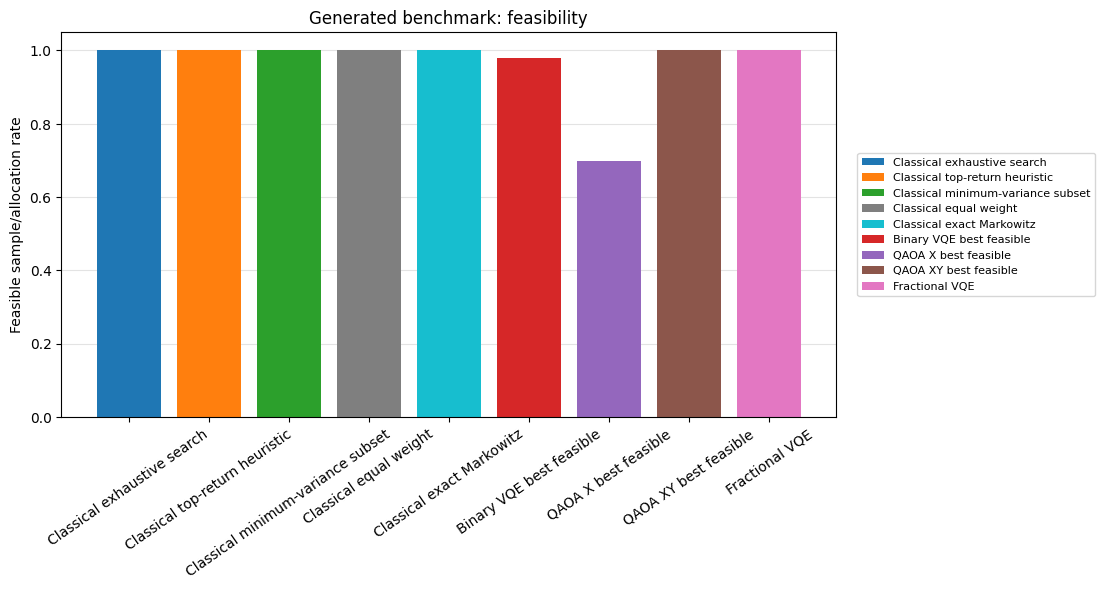

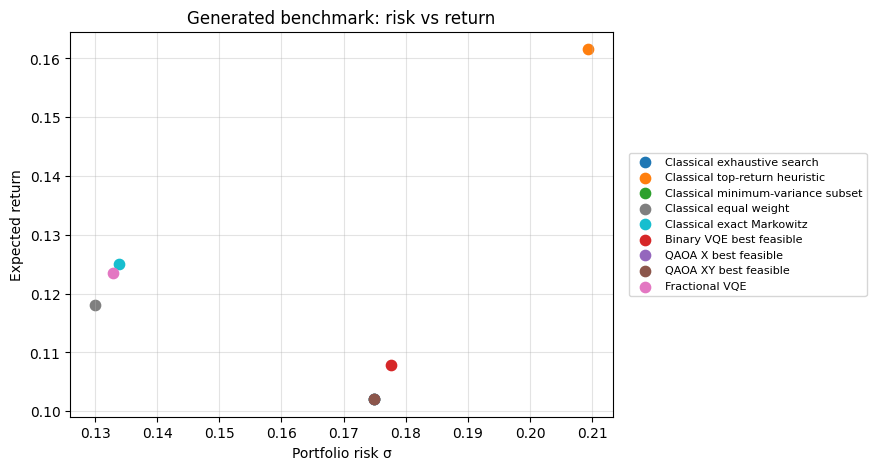

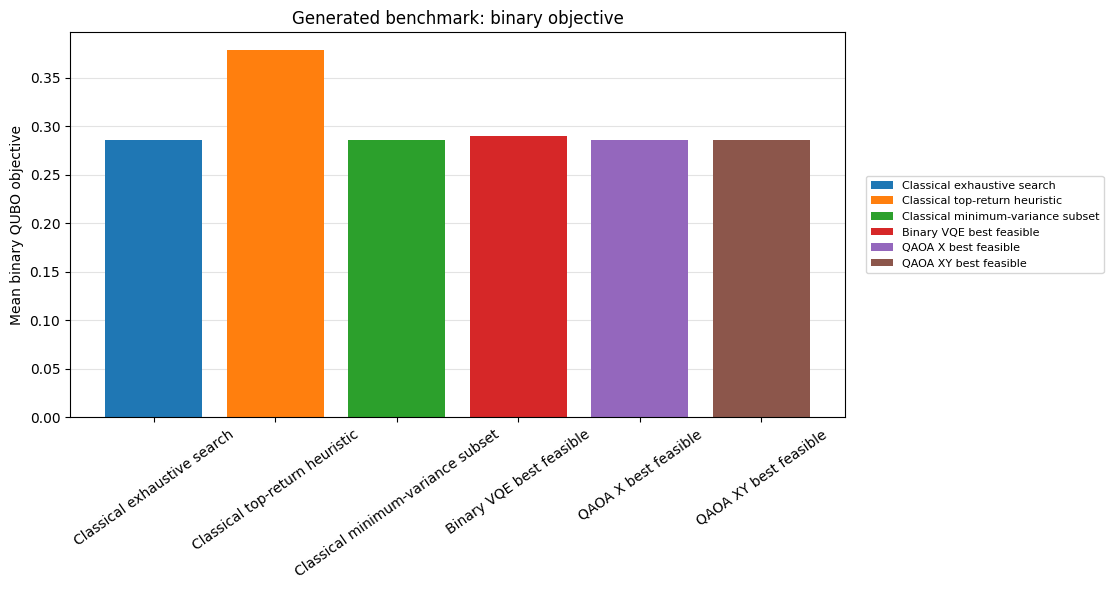

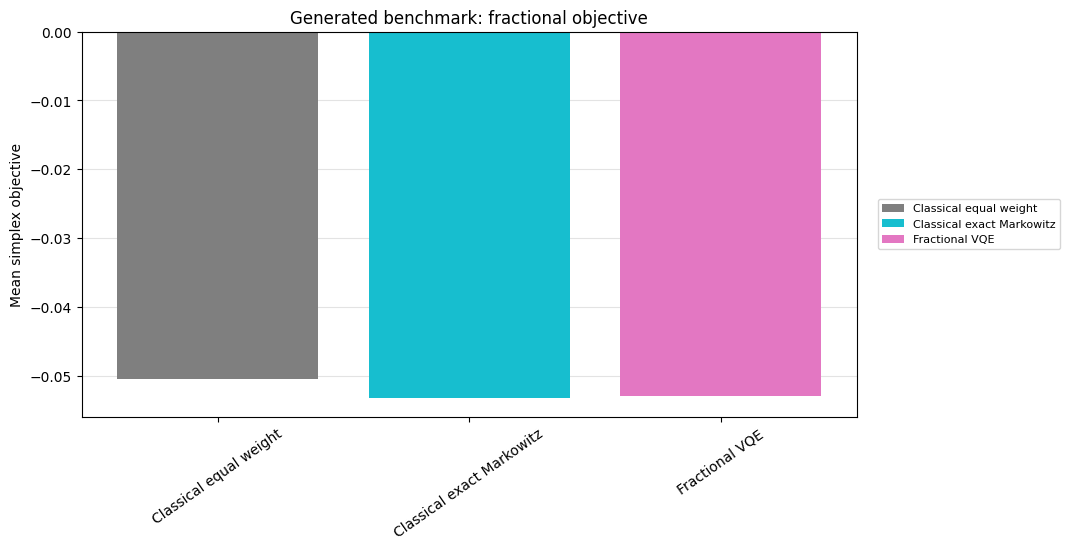

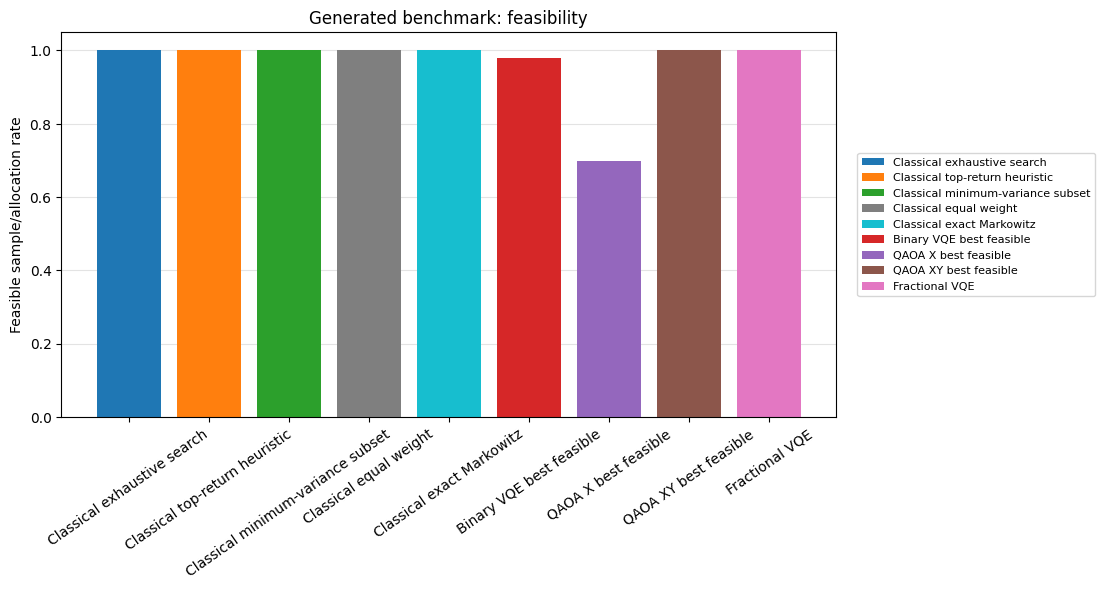

In [6]:
plot_risk_return_comparison(
    summary_rows,
    title="Generated benchmark: risk vs return",
    outpath=IMAGE_DIR / "Generated_Benchmark_Risk_Return.png",
)

binary_rows = [row for row in summary_rows if row["objective_family"] == "binary_qubo"]
fractional_rows = [
    row for row in summary_rows if row["objective_family"] == "fractional_simplex"
]

plot_comparison_metric_bars(
    binary_rows,
    metric="mean_objective",
    ylabel="Mean binary QUBO objective",
    title="Generated benchmark: binary objective",
    outpath=IMAGE_DIR / "Generated_Benchmark_Binary_Objective.png",
)

plot_comparison_metric_bars(
    fractional_rows,
    metric="mean_objective",
    ylabel="Mean simplex objective",
    title="Generated benchmark: fractional objective",
    outpath=IMAGE_DIR / "Generated_Benchmark_Fractional_Objective.png",
)

plot_comparison_metric_bars(
    summary_rows,
    metric="feasible_rate",
    ylabel="Feasible sample/allocation rate",
    title="Generated benchmark: feasibility",
    outpath=IMAGE_DIR / "Generated_Benchmark_Feasibility.png",
)